
# Predicted Blood Vessel Mask for REFUGE using Trained FIVES U-Net

Notebook ini digunakan untuk:
1. mount Google Drive,
2. memuat model U-Net hasil training pada dataset FIVES,
3. membaca semua citra fundus REFUGE,
4. melakukan inferensi blood vessel segmentation,
5. menyimpan predicted mask, overlay, dan ringkasan hasil.

Struktur folder yang diasumsikan:

```text
/content/drive/MyDrive/BV_CDR/
├── models/unet/best_unet_fives.keras
├── REFUG_raw/images/
├── REFUG_raw/masks_cup/
├── REFUG_raw/masks_disc/
└── predictions/refuge/
```


In [ ]:

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:

# Install dependency bila diperlukan
!pip -q install openpyxl


In [ ]:

import os
import glob
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import tensorflow as tf
from tensorflow.keras.models import load_model

print('TensorFlow version:', tf.__version__)
print('GPU available:', tf.config.list_physical_devices('GPU'))


TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:

# CONFIG

BASE_DIR = '/content/drive/MyDrive/BV_CDR'
MODEL_PATH = os.path.join(BASE_DIR, 'models', 'unet', 'best_unet_fives.keras')
REFUGE_DIR = os.path.join(BASE_DIR, 'REFUG_raw')
IMAGE_DIR = os.path.join(REFUGE_DIR, 'images')
CUP_DIR = os.path.join(REFUGE_DIR, 'masks_cup')
DISC_DIR = os.path.join(REFUGE_DIR, 'masks_disc')


LABEL_XLSX = os.path.join(REFUGE_DIR, 'labels', 'refuge_labels.xlsx')
LABEL_CSV  = os.path.join(REFUGE_DIR, 'labels', 'refuge_labels.csv')

PRED_DIR = os.path.join(BASE_DIR, 'predictions', 'refuge')
MASK_PRED_DIR = os.path.join(PRED_DIR, 'masks_pred')
OVERLAY_DIR = os.path.join(PRED_DIR, 'overlay')
PREVIEW_DIR = os.path.join(PRED_DIR, 'previews')
SUMMARY_DIR = os.path.join(PRED_DIR, 'summary')

TARGET_SIZE = (512, 512)
THRESHOLD = 0.5
SAVE_BINARY_MASK = True

for p in [MASK_PRED_DIR, OVERLAY_DIR, PREVIEW_DIR, SUMMARY_DIR]:
    os.makedirs(p, exist_ok=True)

print('MODEL_PATH :', MODEL_PATH)
print('IMAGE_DIR  :', IMAGE_DIR)
print('OUTPUT DIR :', PRED_DIR)


MODEL_PATH : /content/drive/MyDrive/BV_CDR/models/unet/best_unet_fives.keras
IMAGE_DIR  : /content/drive/MyDrive/BV_CDR/REFUG_raw/images
OUTPUT DIR : /content/drive/MyDrive/BV_CDR/predictions/refuge


In [ ]:
# Validasi file dan folder

assert os.path.exists(MODEL_PATH), f'Model tidak ditemukan: {MODEL_PATH}'
assert os.path.exists(IMAGE_DIR), f'Folder image tidak ditemukan: {IMAGE_DIR}'

image_paths = sorted(glob.glob(os.path.join(IMAGE_DIR, '*')))
image_paths = [p for p in image_paths if os.path.isfile(p)]

print('Jumlah image REFUGE:', len(image_paths))
print('Contoh file:')
for x in image_paths[:5]:
    print('-', os.path.basename(x))


Jumlah image REFUGE: 400
Contoh file:
- REFUGE1-train-1.png
- REFUGE1-train-10.png
- REFUGE1-train-100.png
- REFUGE1-train-101.png
- REFUGE1-train-102.png


In [ ]:
# Load label jika tersedia

labels_df = None
if os.path.exists(LABEL_XLSX):
    labels_df = pd.read_excel(LABEL_XLSX)
elif os.path.exists(LABEL_CSV):
    labels_df = pd.read_csv(LABEL_CSV)

if labels_df is not None:
    print('Label file ditemukan')
    print(labels_df.head())
    print('Jumlah label:', len(labels_df))
else:
    print('Label file tidak ditemukan. Notebook tetap bisa berjalan untuk prediksi mask.')


Label file tidak ditemukan. Notebook tetap bisa berjalan untuk prediksi mask.


In [ ]:
# Load model (compile=False cukup untuk inferensi)

model = load_model(MODEL_PATH, compile=False)
model.summary()


Model: "UNet_FIVES_Vessel"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 512, 512,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc1_conv1 (Conv2D) │ (None, 512, 512,  │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc1_bn1            │ (None, 512, 512,  │        128 │ enc1_conv1[0][0]  │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc1_relu1          │ (None, 512, 512,  │          0 │ enc1_bn1[0][0]    │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc1_conv2 (Conv2D) │ (None, 512, 512,  │      9,248 │ enc1_relu1[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc1_bn2            │ (None, 512, 512,  │        128 │ enc1_conv2[0][0]  │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc1_relu2          │ (None, 512, 512,  │          0 │ enc1_bn2[0][0]    │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc1_pool           │ (None, 256, 256,  │          0 │ enc1_relu2[0][0]  │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc2_conv1 (Conv2D) │ (None, 256, 256,  │     18,496 │ enc1_pool[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc2_bn1            │ (None, 256, 256,  │        256 │ enc2_conv1[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc2_relu1          │ (None, 256, 256,  │          0 │ enc2_bn1[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc2_conv2 (Conv2D) │ (None, 256, 256,  │     36,928 │ enc2_relu1[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc2_bn2            │ (None, 256, 256,  │        256 │ enc2_conv2[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc2_relu2          │ (None, 256, 256,  │          0 │ enc2_bn2[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc2_pool           │ (None, 128, 128,  │          0 │ enc2_relu2[0][0]  │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc3_conv1 (Conv2D) │ (None, 128, 128,  │     73,856 │ enc2_pool[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc3_bn1            │ (None, 128, 128,  │        512 │ enc3_conv1[0][0]

 Total params: 7,771,873 (29.65 MB)

 Trainable params: 7,765,985 (29.62 MB)

 Non-trainable params: 5,888 (23.00 KB)

In [ ]:
# Fungsi bantu

def load_and_preprocess_image(image_path, target_size=(512, 512)):
    image_bgr = cv2.imread(image_path, cv2.IMREAD_COLOR)
    if image_bgr is None:
        raise ValueError(f'Gagal membaca image: {image_path}')
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    original_h, original_w = image_rgb.shape[:2]

    resized = cv2.resize(image_rgb, target_size, interpolation=cv2.INTER_AREA)
    normalized = resized.astype(np.float32) / 255.0
    return image_rgb, normalized, (original_h, original_w)


def predict_mask(image_array_norm, model, threshold=0.5):
    inp = np.expand_dims(image_array_norm, axis=0)
    pred = model.predict(inp, verbose=0)[0]

    # handle output shape: (H,W,1) atau (H,W)
    if pred.ndim == 3 and pred.shape[-1] == 1:
        pred = pred[..., 0]

    pred_prob = pred.astype(np.float32)
    pred_bin = (pred_prob >= threshold).astype(np.uint8)
    return pred_prob, pred_bin


def resize_mask_to_original(mask, original_size):
    original_h, original_w = original_size
    return cv2.resize(mask, (original_w, original_h), interpolation=cv2.INTER_NEAREST)


def create_overlay(image_rgb, mask_bin, alpha=0.35):
    overlay = image_rgb.copy()
    color_layer = np.zeros_like(image_rgb)
    color_layer[..., 1] = 255  # hijau

    vessel_region = mask_bin > 0
    overlay[vessel_region] = (
        (1 - alpha) * overlay[vessel_region] + alpha * color_layer[vessel_region]
    ).astype(np.uint8)
    return overlay


Sample: REFUGE1-train-1.png
Original size: (512, 512)
Pred small shape: (512, 512)
Pred original shape: (512, 512)


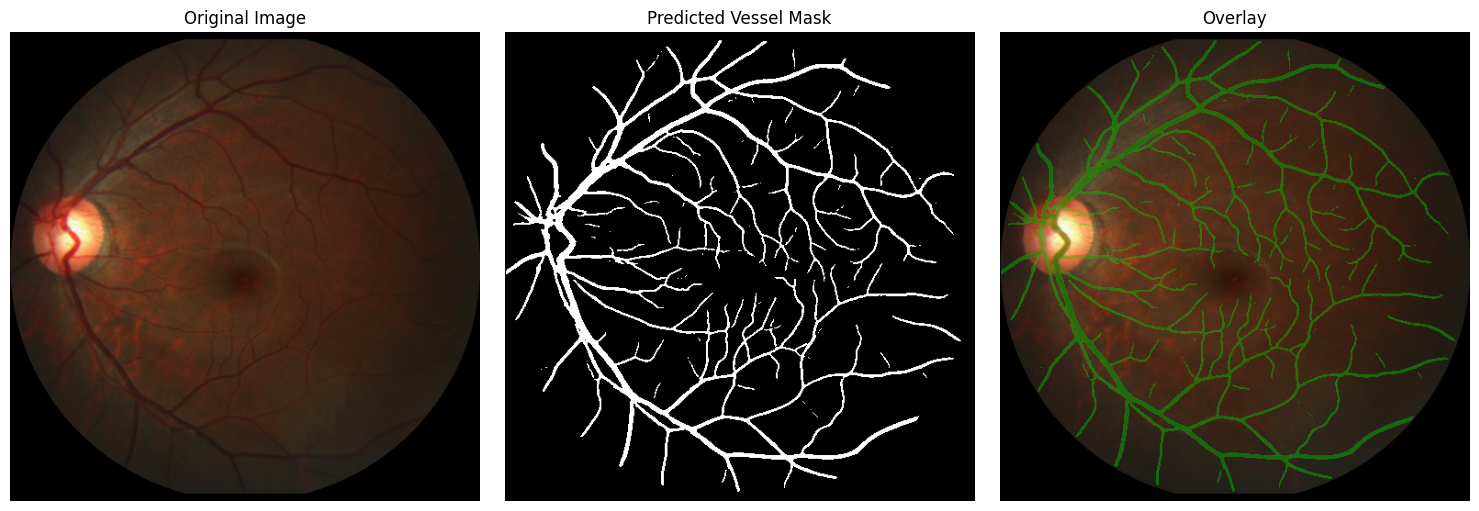

In [ ]:
# Uji 1 gambar

sample_path = image_paths[0]
image_rgb, image_norm, original_size = load_and_preprocess_image(sample_path, TARGET_SIZE)
pred_prob_small, pred_bin_small = predict_mask(image_norm, model, THRESHOLD)
pred_bin_original = resize_mask_to_original(pred_bin_small, original_size)
overlay = create_overlay(image_rgb, pred_bin_original)

print('Sample:', os.path.basename(sample_path))
print('Original size:', original_size)
print('Pred small shape:', pred_bin_small.shape)
print('Pred original shape:', pred_bin_original.shape)

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(image_rgb)
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(pred_bin_original, cmap='gray')
plt.title('Predicted Vessel Mask')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(overlay)
plt.title('Overlay')
plt.axis('off')
plt.tight_layout()
plt.show()


In [ ]:
# prediksi image REFUGE dan simpan

summary_rows = []

for image_path in tqdm(image_paths, desc='Predicting REFUGE vessel masks'):
    filename = os.path.basename(image_path)
    stem, _ = os.path.splitext(filename)

    image_rgb, image_norm, original_size = load_and_preprocess_image(image_path, TARGET_SIZE)
    pred_prob_small, pred_bin_small = predict_mask(image_norm, model, THRESHOLD)
    pred_bin_original = resize_mask_to_original(pred_bin_small, original_size)
    overlay = create_overlay(image_rgb, pred_bin_original)

    # simpan mask binary 0/255
    if SAVE_BINARY_MASK:
        mask_to_save = (pred_bin_original * 255).astype(np.uint8)
    else:
        mask_to_save = pred_bin_original.astype(np.uint8)

    mask_save_path = os.path.join(MASK_PRED_DIR, f'{stem}.png')
    overlay_save_path = os.path.join(OVERLAY_DIR, f'{stem}_overlay.png')

    cv2.imwrite(mask_save_path, mask_to_save)
    cv2.imwrite(overlay_save_path, cv2.cvtColor(overlay, cv2.COLOR_RGB2BGR))

    vessel_pixels = int(np.sum(pred_bin_original > 0))
    total_pixels = int(pred_bin_original.size)
    vessel_ratio = vessel_pixels / total_pixels

    summary_rows.append({
        'filename': filename,
        'name_no_ext': stem,
        'image_path': image_path,
        'mask_pred_path': mask_save_path,
        'overlay_path': overlay_save_path,
        'original_height': original_size[0],
        'original_width': original_size[1],
        'vessel_pixels': vessel_pixels,
        'total_pixels': total_pixels,
        'vessel_ratio': vessel_ratio,
    })

summary_df = pd.DataFrame(summary_rows)
print('Jumlah hasil prediksi:', len(summary_df))
summary_df.head()


Predicting REFUGE vessel masks:   0%|          | 0/400 [00:00<?, ?it/s]

Jumlah hasil prediksi: 400


,filename,name_no_ext,image_path,mask_pred_path,overlay_path,original_height,original_width,vessel_pixels,total_pixels,vessel_ratio
0,REFUGE1-train-1.png,REFUGE1-train-1,/content/drive/MyDrive/BV_CDR/REFUG_raw/images...,/content/drive/MyDrive/BV_CDR/predictions/refu...,/content/drive/MyDrive/BV_CDR/predictions/refu...,512,512,25214,262144,0.096184
1,REFUGE1-train-10.png,REFUGE1-train-10,/content/drive/MyDrive/BV_CDR/REFUG_raw/images...,/content/drive/MyDrive/BV_CDR/predictions/refu...,/content/drive/MyDrive/BV_CDR/predictions/refu...,512,512,26710,262144,0.101891
2,REFUGE1-train-100.png,REFUGE1-train-100,/content/drive/MyDrive/BV_CDR/REFUG_raw/images...,/content/drive/MyDrive/BV_CDR/predictions/refu...,/content/drive/MyDrive/BV_CDR/predictions/refu...,512,512,22884,262144,0.087296
3,REFUGE1-train-101.png,REFUGE1-train-101,/content/drive/MyDrive/BV_CDR/REFUG_raw/images...,/content/drive/MyDrive/BV_CDR/predictions/refu...,/content/drive/MyDrive/BV_CDR/predictions/refu...,512,512,26374,262144,0.100609
4,REFUGE1-train-102.png,REFUGE1-train-102,/content/drive/MyDrive/BV_CDR/REFUG_raw/images...,/content/drive/MyDrive/BV_CDR/predictions/refu...,/content/drive/MyDrive/BV_CDR/predictions/refu...,512,512,25434,262144,0.097023


In [ ]:
# Penggabungan label

if labels_df is not None:
    temp = labels_df.copy()

    # normalisasi nama kolom
    temp.columns = [str(c).strip() for c in temp.columns]

    # cari kolom nama dan label
    possible_name_cols = ['NAME', 'Name', 'name', 'filename', 'FILENAME']
    possible_label_cols = ['LABELS', 'Labels', 'labels', 'label', 'LABEL']

    name_col = next((c for c in possible_name_cols if c in temp.columns), None)
    label_col = next((c for c in possible_label_cols if c in temp.columns), None)

    if name_col is not None:
        temp['name_no_ext'] = temp[name_col].astype(str).str.replace('.png', '', regex=False)

    if name_col is not None and label_col is not None:
        temp = temp[['name_no_ext', label_col]].rename(columns={label_col: 'label'})
        summary_df = summary_df.merge(temp, on='name_no_ext', how='left')
        print('Label berhasil digabungkan ke summary_df')
    else:
        print('Kolom nama/label tidak ditemukan otomatis. Summary tanpa label.')

summary_df.head()


,filename,name_no_ext,image_path,mask_pred_path,overlay_path,original_height,original_width,vessel_pixels,total_pixels,vessel_ratio
0,REFUGE1-train-1.png,REFUGE1-train-1,/content/drive/MyDrive/BV_CDR/REFUG_raw/images...,/content/drive/MyDrive/BV_CDR/predictions/refu...,/content/drive/MyDrive/BV_CDR/predictions/refu...,512,512,25214,262144,0.096184
1,REFUGE1-train-10.png,REFUGE1-train-10,/content/drive/MyDrive/BV_CDR/REFUG_raw/images...,/content/drive/MyDrive/BV_CDR/predictions/refu...,/content/drive/MyDrive/BV_CDR/predictions/refu...,512,512,26710,262144,0.101891
2,REFUGE1-train-100.png,REFUGE1-train-100,/content/drive/MyDrive/BV_CDR/REFUG_raw/images...,/content/drive/MyDrive/BV_CDR/predictions/refu...,/content/drive/MyDrive/BV_CDR/predictions/refu...,512,512,22884,262144,0.087296
3,REFUGE1-train-101.png,REFUGE1-train-101,/content/drive/MyDrive/BV_CDR/REFUG_raw/images...,/content/drive/MyDrive/BV_CDR/predictions/refu...,/content/drive/MyDrive/BV_CDR/predictions/refu...,512,512,26374,262144,0.100609
4,REFUGE1-train-102.png,REFUGE1-train-102,/content/drive/MyDrive/BV_CDR/REFUG_raw/images...,/content/drive/MyDrive/BV_CDR/predictions/refu...,/content/drive/MyDrive/BV_CDR/predictions/refu...,512,512,25434,262144,0.097023


In [ ]:
# Simpan ringkasan hasil prediksi

summary_csv = os.path.join(SUMMARY_DIR, 'refuge_vessel_prediction_summary.csv')
summary_xlsx = os.path.join(SUMMARY_DIR, 'refuge_vessel_prediction_summary.xlsx')

summary_df.to_csv(summary_csv, index=False)
summary_df.to_excel(summary_xlsx, index=False)

print('Summary CSV :', summary_csv)
print('Summary XLSX:', summary_xlsx)


Summary CSV : /content/drive/MyDrive/BV_CDR/predictions/refuge/summary/refuge_vessel_prediction_summary.csv
Summary XLSX: /content/drive/MyDrive/BV_CDR/predictions/refuge/summary/refuge_vessel_prediction_summary.xlsx


In [ ]:
# Visualisasi hasil prediksi

preview_n = min(9, len(summary_df))
sample_df = summary_df.sample(n=preview_n, random_state=42) if len(summary_df) > preview_n else summary_df.copy()

plt.figure(figsize=(15, 5 * preview_n))
for i, row in enumerate(sample_df.itertuples(index=False), start=1):
    img = cv2.cvtColor(cv2.imread(row.image_path), cv2.COLOR_BGR2RGB)
    msk = cv2.imread(row.mask_pred_path, cv2.IMREAD_GRAYSCALE)
    ovl = cv2.cvtColor(cv2.imread(row.overlay_path), cv2.COLOR_BGR2RGB)

    plt.subplot(preview_n, 3, (i - 1) * 3 + 1)
    plt.imshow(img)
    plt.title(f'Image {row.filename}')
    plt.axis('off')

    plt.subplot(preview_n, 3, (i - 1) * 3 + 2)
    plt.imshow(msk, cmap='gray')
    plt.title('Predicted Mask')
    plt.axis('off')

    plt.subplot(preview_n, 3, (i - 1) * 3 + 3)
    plt.imshow(ovl)
    plt.title('Overlay')
    plt.axis('off')

plt.tight_layout()
plt.show()


Output hidden; open in https://colab.research.google.com to view.

In [ ]:
# Simpan contact sheet preview ke Drive

preview_n = min(12, len(summary_df))
sample_df = summary_df.sample(n=preview_n, random_state=123) if len(summary_df) > preview_n else summary_df.copy()

fig = plt.figure(figsize=(15, 4 * preview_n))
for i, row in enumerate(sample_df.itertuples(index=False), start=1):
    img = cv2.cvtColor(cv2.imread(row.image_path), cv2.COLOR_BGR2RGB)
    msk = cv2.imread(row.mask_pred_path, cv2.IMREAD_GRAYSCALE)
    ovl = cv2.cvtColor(cv2.imread(row.overlay_path), cv2.COLOR_BGR2RGB)

    ax1 = plt.subplot(preview_n, 3, (i - 1) * 3 + 1)
    ax1.imshow(img)
    ax1.set_title(f'Image{row.filename}')
    ax1.axis('off')

    ax2 = plt.subplot(preview_n, 3, (i - 1) * 3 + 2)
    ax2.imshow(msk, cmap='gray')
    ax2.set_title('Predicted Mask')
    ax2.axis('off')

    ax3 = plt.subplot(preview_n, 3, (i - 1) * 3 + 3)
    ax3.imshow(ovl)
    ax3.set_title('Overlay')
    ax3.axis('off')

plt.tight_layout()
preview_path = os.path.join(PREVIEW_DIR, 'refuge_prediction_previews.png')
plt.savefig(preview_path, dpi=200, bbox_inches='tight')
plt.show()
print('Preview saved to:', preview_path)


Output hidden; open in https://colab.research.google.com to view.

In [ ]:

# Statistik sederhana hasil prediksi
print('Jumlah image diproses :', len(summary_df))
print('Rata-rata vessel ratio:', round(summary_df['vessel_ratio'].mean(), 6))
print('Min vessel ratio      :', round(summary_df['vessel_ratio'].min(), 6))
print('Max vessel ratio      :', round(summary_df['vessel_ratio'].max(), 6))

if 'label' in summary_df.columns:
    print('Distribusi label:')
    print(summary_df['label'].value_counts(dropna=False))


Jumlah image diproses : 400
Rata-rata vessel ratio: 0.095228
Min vessel ratio      : 0.03904
Max vessel ratio      : 0.127399


output file:

```text
/content/drive/MyDrive/BV_CDR/predictions/refuge/masks_pred/
/content/drive/MyDrive/BV_CDR/predictions/refuge/overlay/
/content/drive/MyDrive/BV_CDR/predictions/refuge/previews/
/content/drive/MyDrive/BV_CDR/predictions/refuge/summary/
```

File ringkasan utama:

```text
refuge_vessel_prediction_summary.csv
refuge_vessel_prediction_summary.xlsx
```